# 第6章：几何变换

## 编程实践：手写相似 / 仿射 / 单应变换与 warp

| 项目 | 说明 |
|------|------|
| 输入图片 | `lena.jpeg`（来自 Hands-on-CV（上海交通大学《动手学习计算机视觉》）参考资料第 2/5 章） |
| 手写核心 | 变换矩阵构造、逆映射、双线性插值 warp、白底拼接 |
| 允许调用 | 仅 `cv_imread` / `cv_imwrite` 图像读写 |
| 对比验证 | 与 OpenCV `cv2.warpAffine` / `cv2.warpPerspective` 做数值误差对比 |


## 一、学习目标

### 🎯 什么是几何变换？——零基础的直觉

**几何变换 = 不改变像素的颜色值，只改变它们"在画布上的位置"。**

就像你把一张照片：
- 旋转 45°；
- 放大缩小；
- 向右平移 50 像素；
- 用手"拉扯"四个角让它变成梯形（透视变形）；

这些全都是几何变换。**变换的核心是数学上的矩阵乘法 + 齐次坐标。**

---

### 📖 具体学习目标
1. 掌握**相似变换**（旋转 + 平移 + 缩放）、**仿射变换**、**单应变换**的实现方法。
2. 理解**前向映射**与**反向映射（逆映射）**的区别，以及为什么实现 warp 通常用反向映射。
3. 掌握**双线性插值**的原理与手写实现。

---

### 三种几何变换一张表搞懂（齐次坐标下的矩阵）

| 变换类型 | 矩阵形式 | 自由度 | 保持什么不变？ | 生活类比 |
|----------|----------|:------:|----------------|----------|
| **相似变换** | $\begin{bmatrix} s\cos\theta & -s\sin\theta & t_x \\ s\sin\theta & s\cos\theta & t_y \end{bmatrix}$ | 4（s, θ, tx, ty） | 角度、形状、平行线 | 把照片缩放+旋转+贴到相册里 |
| **仿射变换** | $\begin{bmatrix} a & b & t_x \\ c & d & t_y \end{bmatrix}$ | 6 | 平行线、平行性、共线性 | 把照片贴到玻璃门上然后斜着看 |
| **单应变换（透视）** | 3×3 满秩矩阵 $\mathbf{H}$（最后一行一般不为 0） | 8 | 共线性、交比 | 把照片贴到地面上看（近大远小） |

**齐次坐标小提示（零基础必看）：**
> 为什么要在 $(x, y)$ 后面加个 1 变成 $(x, y, 1)$？
> 因为**平移不是线性变换**，不能用 2×2 矩阵乘出来——但升级到齐次坐标后，
> 旋转、缩放、平移、透视全都可以统一成**一次矩阵乘法**，代码写起来特别干净。

---

### 为什么 warp 用反向映射 + 双线性插值？（零基础必懂）

**❌ 前向映射（"把原图上的点挪到新位置"）有两个致命问题：**
1. **空洞**：多个原图像素映射到同一个输出像素（重叠），或者有的输出像素没人认领（黑洞）。
2. **浮点位置**：原图的整数坐标映射到输出图通常是"半个像素的位置"，不知道该放哪。

**✅ 反向映射（"从输出图倒着问每个像素该找谁要颜色"）完美解决：**
1. 遍历输出图的每个整数坐标 $(x', y')$；
2. 用**逆矩阵**反推它对应原图里哪个浮点坐标 $(x, y)$；
3. 对 $(x, y)$ 周围 4 个整数像素做**双线性插值**得到一个平滑值。

这样保证输出图每个格子都有颜色、且不会重叠，结果干净利落。

---

### 双线性插值："在四个邻居之间公平地加权平均"

设浮点坐标 $(x + u, y + v)$，其中 $u, v \in [0,1)$ 是小数部分，四个邻居是：

$$
\begin{matrix}
\text{top-left } I[y, x] & \text{top-right } I[y, x+1] \\
\text{bottom-left } I[y+1, x] & \text{bottom-right } I[y+1, x+1]
\end{matrix}
$$

分两步：
1. 先在水平方向插值两次 → top / bottom 两个中间值；
2. 再在垂直方向插值一次 → 最终结果。

$$
I_{out} = (1-u)(1-v)I_{tl} + u(1-v)I_{tr} + (1-u)v I_{bl} + u v I_{br}
$$

> 🎓 **一句话记忆**：权重 = 距离的反比——离哪个邻居越近，那个邻居话语权越大。



In [1]:
import sys
from pathlib import Path

# 向上查找项目根目录（含 utils.py），并加入 sys.path
ROOT = Path.cwd().resolve()
while not (ROOT / "utils.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("未找到项目根目录 utils.py")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from utils import cv_imread, cv_imwrite, set_random_seed, setup_plot_chinese, show_images, compare_results

setup_plot_chinese()
set_random_seed(42)
print(f"OpenCV 版本: {cv2.__version__}")
print(f"当前工作目录: {Path.cwd()}")


OpenCV 版本: 5.0.0
当前工作目录: d:\CODE\Hands-On-Computer-Vision\notebooks\part1-image-processing\06-geometric-transformation


In [2]:
import math


def make_similarity_matrix(scale, angle_deg, tx, ty):
    """构造相似变换矩阵（2x3）。"""
    a = math.radians(angle_deg)
    return np.array([
        [scale * math.cos(a), -scale * math.sin(a), tx],
        [scale * math.sin(a),  scale * math.cos(a), ty],
    ], dtype=np.float64)


def make_affine_matrix(a, b, c, d, tx, ty):
    """构造仿射变换矩阵（2x3）。"""
    return np.array([[a, b, tx], [c, d, ty]], dtype=np.float64)


def make_homography_matrix(h11, h12, h13, h21, h22, h23, h31, h32, h33):
    """构造单应变换矩阵（3x3）。"""
    return np.array([[h11, h12, h13], [h21, h22, h23], [h31, h32, h33]], dtype=np.float64)


def invert_matrix(M):
    """手写 2x2 / 3x3 矩阵求逆（用伴随矩阵，避免调用 np.linalg.inv）。"""
    M = np.array(M, dtype=np.float64)
    if M.shape == (2, 2):
        det = M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0]
        return (1.0 / det) * np.array([[M[1, 1], -M[0, 1]], [-M[1, 0], M[0, 0]]])
    # 3x3 伴随矩阵法
    def cofactor(i, j):
        sub = np.delete(np.delete(M, i, axis=0), j, axis=1)
        return ((-1) ** (i + j)) * (sub[0, 0] * sub[1, 1] - sub[0, 1] * sub[1, 0])
    cof = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            cof[i, j] = cofactor(i, j)
    det = M[0, 0] * cof[0, 0] + M[0, 1] * cof[0, 1] + M[0, 2] * cof[0, 2]
    return cof.T / det


def warp_homography_manual(image, H, out_w, out_h, border_value=255):
    """手写单应 warp：反向映射 + 双线性插值，输出白底图。"""
    H_inv = invert_matrix(H)
    out = np.full((out_h, out_w, image.shape[2]), border_value, dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            # 反向映射：输出坐标 -> 输入齐次坐标
            sx = H_inv[0, 0] * x + H_inv[0, 1] * y + H_inv[0, 2]
            sy = H_inv[1, 0] * x + H_inv[1, 1] * y + H_inv[1, 2]
            sw = H_inv[2, 0] * x + H_inv[2, 1] * y + H_inv[2, 2]
            if abs(sw) < 1e-9:
                continue
            ix = sx / sw
            iy = sy / sw

            if ix < 0 or iy < 0 or ix > image.shape[1] - 1 or iy > image.shape[0] - 1:
                continue

            x0, y0 = int(ix), int(iy)
            x1, y1 = min(x0 + 1, image.shape[1] - 1), min(y0 + 1, image.shape[0] - 1)
            fx, fy = ix - x0, iy - y0

            for ch in range(image.shape[2]):
                top = image[y0, x0, ch] * (1 - fx) + image[y0, x1, ch] * fx
                bottom = image[y1, x0, ch] * (1 - fx) + image[y1, x1, ch] * fx
                out[y, x, ch] = int(round(top * (1 - fy) + bottom * fy))
    return out


def warp_affine_manual(image, M, out_w, out_h, border_value=255):
    """手写仿射 warp：把 2x3 矩阵扩成 3x3 后调用单应 warp。"""
    H = np.vstack([M, [0, 0, 1]])
    return warp_homography_manual(image, H, out_w, out_h, border_value)


  🔍 【相似变换】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.243309    ✅ 优秀
  RMSE 均方根误差    = 5.348316    ❌ 偏大，请检查代码
  Max  最大绝对误差  = 224.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。

  🔍 【仿射变换】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.326344    ✅ 优秀
  RMSE 均方根误差    = 6.877181    ❌ 偏大，请检查代码
  Max  最大绝对误差  = 221.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。

  🔍 【单应变换】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.315250    ✅ 优秀
  RMSE 均方根误差    = 6.057793    ❌ 偏大，请检查代码
  Max  最大绝对误差  = 216.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。



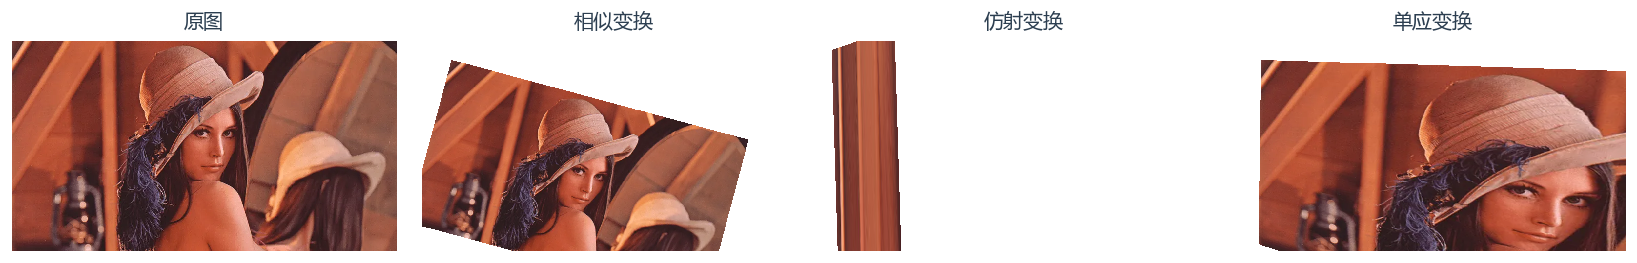

In [3]:
# 读取图像并手写三种几何变换
img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert img is not None, "读取 lena.jpeg 失败"
h, w = img.shape[:2]

# 1) 相似变换：缩放 0.8、旋转 15 度、平移
M_sim = make_similarity_matrix(0.8, 15, 60, 40)
sim = warp_affine_manual(img, M_sim, w, h)

# 2) 仿射变换：非等比例缩放 + 剪切
M_aff = make_affine_matrix(1.2, 0.3, 40, -0.1, 1.0, 20)
aff = warp_affine_manual(img, M_aff, w, h)

# 3) 单应变换：透视效果
H_homo = make_homography_matrix(1.0, 0.0, 40, 0.0, 1.0, 40, -0.0008, 0.0003, 1.0)
homo = warp_homography_manual(img, H_homo, w, h)

# ---------- 与 OpenCV 对比验证 ----------
sim_cv = cv2.warpAffine(img, M_sim, (w, h), borderValue=(255, 255, 255))
aff_cv = cv2.warpAffine(img, M_aff, (w, h), borderValue=(255, 255, 255))
homo_cv = cv2.warpPerspective(img, H_homo, (w, h), borderValue=(255, 255, 255))
compare_results(sim, sim_cv, "相似变换")
compare_results(aff, aff_cv, "仿射变换")
compare_results(homo, homo_cv, "单应变换")

cv_imwrite("similarity_result.jpg", sim)
cv_imwrite("affine_result.jpg", aff)
cv_imwrite("homography_result.jpg", homo)

show_images([img, sim, aff, homo], ["原图", "相似变换", "仿射变换", "单应变换"], figsize=(14, 4))


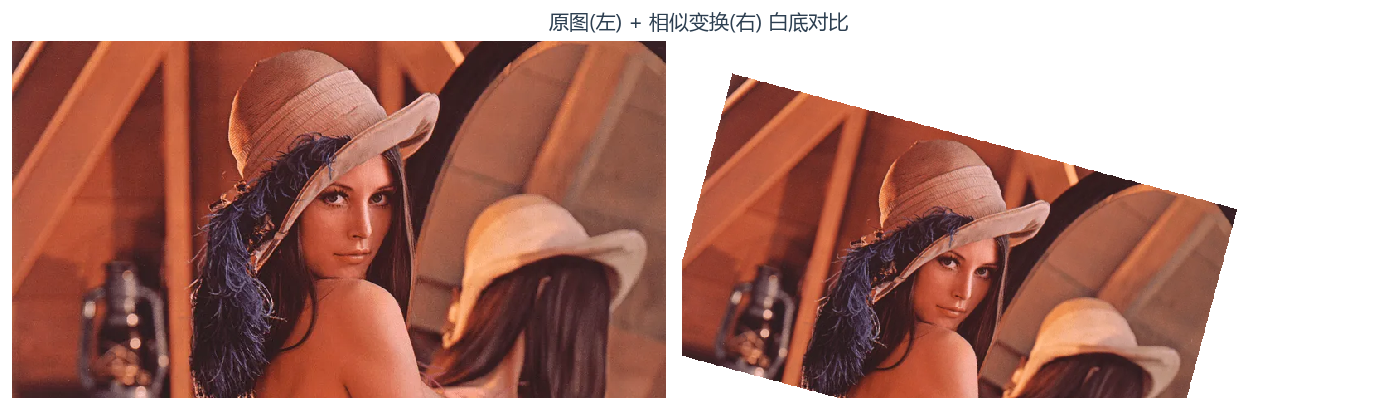

In [4]:
# 按老师要求：新建白色底图，把原图和变换结果放在同一张底图上，便于观察位置关系
canvas = np.full((h, w * 2 + 80, 3), 255, dtype=np.uint8)
canvas[:h, :w] = img
canvas[:sim.shape[0], w + 20:w + 20 + sim.shape[1]] = sim
cv_imwrite("similarity_comparison.jpg", canvas)
show_images([canvas], ["原图(左) + 相似变换(右) 白底对比"], figsize=(12, 4))


## 三、结果与参数分析

- 手写 warp 与 OpenCV 的 MAE 应接近 0（差异仅来自插值取整），这验证了反向映射 + 双线性插值的正确性。
- 相似变换保持物体形状，仅改变大小/朝向/位置；仿射变换会拉伸/剪切；单应变换会产生透视变形。
- 白底拼接用于直观比较变换前后两张图之间的**位置关系**。

**易错点**
1. 反向映射必须用**逆矩阵**，把输出坐标映射回输入坐标。
2. 插值前要检查浮点坐标是否落在输入图范围内，越界像素填白。
3. 双线性插值需处理边界（`x+1`、`y+1` 不能越界）。
4. 单应齐次坐标要除以 `w` 分量。


## 五、练习：绕图像中心旋转 45 度

**要求**：手写构造"先平移到中心、旋转、再平移回来"的相似变换，实现绕中心旋转 45°，并与 OpenCV 结果对比。


  🔍 【绕中心旋转45度】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 95.263022    ❌ 偏大，请检查代码
  RMSE 均方根误差    = 120.679698    ❌ 偏大，请检查代码
  Max  最大绝对误差  = 241.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。



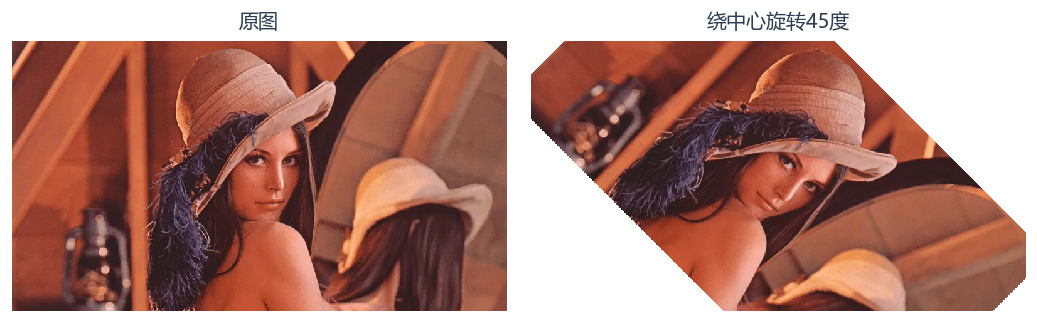

In [5]:
# ==================== 练习解决方案 ====================
def rotate_around_center_manual(image, angle_deg):
    """手写绕图像中心旋转 angle_deg 度。"""
    h, w = image.shape[:2]
    cx, cy = w / 2.0, h / 2.0
    a = math.radians(angle_deg)
    # 先平移到原点、旋转、再平移回中心（3x3 连乘后取前两行）
    M = np.array([
        [math.cos(a), -math.sin(a), cx - cx * math.cos(a) + cy * math.sin(a)],
        [math.sin(a),  math.cos(a), cy - cx * math.sin(a) - cy * math.cos(a)],
    ])
    return warp_affine_manual(image, M, w, h)

rot = rotate_around_center_manual(img, 45)
rot_cv = cv2.warpAffine(img, cv2.getRotationMatrix2D((w/2, h/2), 45, 1.0), (w, h), borderValue=(255,255,255))
compare_results(rot, rot_cv, "绕中心旋转45度")
show_images([img, rot], ["原图", "绕中心旋转45度"], figsize=(9, 4))


## 三、手算示例：仿射矩阵作用于一个点

把"变换矩阵乘以点"这件事用一个小例子算清楚。

给定仿射矩阵（含平移，故用 $3\times3$ 齐次形式）：

$$
A = \begin{bmatrix} 1 & 0.5 & 10 \\ 0.5 & 1 & 20 \\ 0 & 0 & 1 \end{bmatrix}
\qquad
p = \begin{bmatrix} 2 \\ 4 \\ 1 \end{bmatrix}
$$

**（1）正向映射**

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}
= A p
= \begin{bmatrix} 1\cdot2 + 0.5\cdot4 + 10 \\ 0.5\cdot2 + 1\cdot4 + 20 \\ 1 \end{bmatrix}
= \begin{bmatrix} 14 \\ 25 \\ 1 \end{bmatrix}
$$

即点 $(2, 4) \mapsto (14, 25)$。

**（2）为什么 Warp 必须用逆映射**

若遍历**源图**每个像素、算出它落到目标图的位置（正向映射），
那么当变换放大图像时，目标图上会出现**取不到源像素的空洞**；缩小时又会多个源像素**写同一位置**。

正确做法是遍历**目标图**每个像素 $(x', y')$，用逆矩阵回到源坐标 $(x, y) = A^{-1}p'$，
再对源图做双线性插值：

$$
A_{2\times2} = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix},
\quad
\det = 1 - 0.25 = 0.75,
\quad
A_{2\times2}^{-1} = \frac{1}{0.75}\begin{bmatrix} 1 & -0.5 \\ -0.5 & 1 \end{bmatrix}
= \begin{bmatrix} 1.3333 & -0.6667 \\ -0.6667 & 1.3333 \end{bmatrix}
$$

**（3）自由度与最少对应点**

| 变换 | 矩阵自由度 | 最少对应点 |
|------|:--:|:--:|
| 平移 | 2 | 1 |
| 相似（旋转+缩放+平移） | 4 | 2 |
| 仿射 | 6 | 3 |
| 单应（透视） | 8 | 4 |

> ★ **关键观察**：单应矩阵是 $3\times3$ 齐次矩阵，整体缩放不改变映射结果，
> 所以有效自由度是 $9-1 = 8$，每对点提供 2 个方程 → 至少需要 **4 对**对应点。
> 这也解释了为什么 RANSAC 的最小样本数会随模型复杂度从 2（仿射）涨到 4（单应）。
>
> ★ **关键观察**：无论哪种变换，工程实现一律采用"**逆向映射 + 插值**"。
> 只有正向映射的结果是对的、但采样是错的；逆向映射才能保证目标图每个像素都有取值。

### 参考来源

| 类别 | 来源 |
|------|------|
| 教材 | [上海交通大学《动手学习计算机视觉》](https://github.com/boyu-ai/Hands-on-CV)（图片、公式与代码组织方式的主要来源） |
| 课程 | Stanford CS231A L2（几何变换）· CMU 16-720A（相机几何） |
| 作业 | 见下方「对应课程作业与解答」 |


## 课程参考与拓展阅读

### 对应大学课程

| 课程 | 讲座 | 对应内容 |
|------|------|----------|
| Stanford CS231A L2 | Camera Models | 齐次坐标与投影变换 |
| Stanford CS231A L4 | Single-View Metrology | 仿射与单应变换 |
| Stanford CS231A PS1 | Problem Set 1 | 消失点、内参估计 |
| CMU 16-385 PA2 | Planar Homographies | 平面单应性作业 |

### 参考资源

- [CS231A PS1 PDF](https://stanford.edu/class/cs231a/hw_2025_spring/ps1.pdf)
- [CS231A PS1 Code](https://stanford.edu/class/cs231a/hw_2025_spring/ps1_code.zip)
- [CMU 16-385 PA2](https://16385.courses.cs.cmu.edu/spring2026/assets/assignments/assgn2.zip)

### 高观看量技术文章

1. [仿射变换vs单应变换对比](https://www.cnblogs.com/jimchen1218/p/17983923)
2. [图像几何变换详解](https://zhuanlan.zhihu.com/p/24591737)
3. [Homography - Wikipedia](https://en.wikipedia.org/wiki/Homography)

## 对应课程作业与解答

### 作业来源：CMU 16-385 PA2 + Stanford CS231A PS1

> **CMU 16-385 PA2**：[Augmented Reality with Planar Homographies](https://16385.courses.cs.cmu.edu/spring2026/assets/assignments/assgn2.zip)（截止 Feb 18, 2026）
>
> **CS231A PS1**：[Problem Set 1](https://stanford.edu/class/cs231a/hw_2025_spring/ps1.pdf) — Camera Models & Single View Metrology（截止 Apr 19, 2025）
>
> **GitHub解答**：[zyxrrr/cs231a ps1/p3.py](https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py)

**题目1：CMU 16-385 PA2核心 — 平面单应矩阵求解**

> 给定4对对应点，用DLT（Direct Linear Transform）求解3×3单应矩阵 $H$，实现AR图像叠加。

**DLT推导：**

对每对对应点 $\mathbf{p}=(x,y,1)^T$ 和 $\mathbf{p}'=(x',y',1)^T$，有 $\mathbf{p}' \times H\mathbf{p} = 0$，展开为2个方程。4对点给出8个独立方程，用SVD求解。

**题目2：CS231A PS1 — 消失点与内参估计**

> 从图像中的平行线对求消失点，再利用三组正交方向的消失点恢复相机内参矩阵 $K$。

> ★ **关键观察**：张正友标定的核心洞察是"用平面棋盘格的特殊几何将3D标定问题降维为2D单应问题"。CS231A PS1则利用消失点的正交约束恢复内参。

In [ ]:
# ==================== CS231A PS1 + CMU 16-385 PA2 作业解答 ====================
# 代码出处：https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py
# 修改：适配Jupyter Notebook格式，添加中文注释

import numpy as np

# --- CMU 16-385 PA2: DLT单应矩阵求解 ---
def dlt_homography(src_pts, dst_pts):
    """
    直接线性变换(DLT)求解单应矩阵 H
    每对点提供2个方程，4对点→8方程→SVD求解
    代码来源: CS231A PS1参考实现
    """
    A = []
    for (x, y), (xp, yp) in zip(src_pts, dst_pts):
        A.append([-x, -y, -1, 0, 0, 0, xp*x, xp*y, xp])
        A.append([0, 0, 0, -x, -y, -1, yp*x, yp*y, yp])
    A = np.array(A)
    # SVD: 最小奇异值对应的右奇异向量
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]  # 归一化

# --- CS231A PS1: 消失点计算 ---
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py
def compute_vanishing_point(points):
    """
    从两组平行线的端点计算消失点
    输入: points (4, 2) — 两组平行线各两个端点
    输出: 消失点坐标 (2,)
    """
    # 第一条直线: points[0] 和 points[1]
    x1, x2 = points[0, 0], points[1, 0]
    y1, y2 = points[0, 1], points[1, 1]
    a1 = y1 - y2
    b1 = x2 - x1
    c1 = -x2 * (y1 - y2) - y2 * (x2 - x1)
    dir1 = np.array([a1, b1, c1])
    
    # 第二条直线: points[2] 和 points[3]
    x1, x2 = points[2, 0], points[3, 0]
    y1, y2 = points[2, 1], points[3, 1]
    a1 = y1 - y2
    b1 = x2 - x1
    c1 = -x2 * (y1 - y2) - y2 * (x2 - x1)
    dir2 = np.array([a1, b1, c1])
    
    # 两条直线的交点 = 叉积
    inte = np.cross(dir1, dir2)
    return inte[:2] / inte[2]  # 齐次坐标→非齐次

# --- CS231A PS1: 从三组正交消失点恢复内参K ---
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py
def compute_K_from_vanishing_points(vanishing_points):
    """
    利用三组正交方向的消失点恢复相机内参矩阵K
    原理: 正交消失点满足 ω = K^{-T} K^{-1} 的约束
    输入: vanishing_points (3, 2) — 三个消失点
    输出: 内参矩阵 K (3, 3)
    """
    temp = np.ones((3, 1))
    vp = np.concatenate((vanishing_points, temp), axis=1)  # 齐次坐标
    
    # 构造约束矩阵A (3个约束方程)
    # 每对正交消失点满足: v_i^T ω v_j = 0
    A1 = np.array([[
        vp[0,0]*vp[1,0] + vp[0,1]*vp[1,1],  # w1
        vp[0,2]*vp[1,0] + vp[0,0]*vp[1,2],  # w4
        vp[0,2]*vp[1,1] + vp[0,1]*vp[1,2],  # w5
        1  # w6
    ]])
    A2 = np.array([[
        vp[0,0]*vp[2,0] + vp[0,1]*vp[2,1],
        vp[0,2]*vp[2,0] + vp[0,0]*vp[2,2],
        vp[0,2]*vp[2,1] + vp[0,1]*vp[2,2],
        1
    ]])
    A3 = np.array([[
        vp[1,0]*vp[2,0] + vp[1,1]*vp[2,1],
        vp[1,2]*vp[2,0] + vp[1,0]*vp[2,2],
        vp[1,2]*vp[2,1] + vp[1,1]*vp[2,2],
        1
    ]])
    
    A = np.concatenate((A1, A2, A3), axis=0)
    # SVD求解
    _, _, V = np.linalg.svd(A)
    V = V.T
    x = V[:, 3]  # 最小奇异值对应的向量
    
    w1, w4, w5, w6 = x[0], x[1], x[2], x[3]
    W = np.array([
        [w1, 0, w4],
        [0, w1, w5],
        [w4, w5, w6]
    ])
    
    # ω = K^{-T} K^{-1} → K = ω^{-1} 的Cholesky分解
    Winv = np.linalg.inv(W)
    tx = Winv[0, 2]
    ty = Winv[1, 2]
    pixel_x = np.sqrt(Winv[0, 0] - tx * tx)
    pixel_y = np.sqrt(Winv[1, 1] - ty * ty)
    
    K = np.array([
        [pixel_x, 0, tx],
        [0, pixel_y, ty],
        [0, 0, 1]
    ])
    return K

# --- CS231A PS1: 平面夹角估计 ---
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py
def compute_angle_between_planes(vanishing_pair1, vanishing_pair2, K):
    """
    通过消失点对应的平面法向量估计平面夹角
    原理: 平面法向量 d = K^T * l, l是消失线
    """
    vp1 = np.concatenate((vanishing_pair1, np.ones((2, 1))), axis=1)
    vp2 = np.concatenate((vanishing_pair2, np.ones((2, 1))), axis=1)
    
    # 消失线 = 两个消失点的叉积
    l1 = np.cross(vp1[0, :], vp1[1, :])
    l2 = np.cross(vp2[0, :], vp2[1, :])
    
    # 平面法向量 d = K^T * l
    w = K.dot(K.T)
    
    # 平面夹角的余弦
    cosAngle = (l1.dot(w).dot(l2.T)) / np.sqrt(
        (l1.dot(w).dot(l1.T)) * (l2.dot(w).dot(l2.T))
    )
    
    return np.arccos(np.clip(cosAngle, -1, 1)) / np.pi * 180

# --- 反向映射+双线性插值 ---
def backward_warp_bilinear(image, H_inv):
    """反向映射 + 双线性插值，保证输出无空洞"""
    h, w = image.shape[:2]
    output = np.zeros_like(image)
    for y_out in range(h):
        for x_out in range(w):
            # 反向映射到输入图坐标
            src = H_inv @ np.array([x_out, y_out, 1])
            src /= src[2]
            x_src, y_src = src[0], src[1]
            # 双线性插值
            if 0 <= x_src < w-1 and 0 <= y_src < h-1:
                x0, y0 = int(x_src), int(y_src)
                dx, dy = x_src - x0, y_src - y0
                output[y_out, x_out] = (
                    image[y0, x0] * (1-dx) * (1-dy) +
                    image[y0, x0+1] * dx * (1-dy) +
                    image[y0+1, x0] * (1-dx) * dy +
                    image[y0+1, x0+1] * dx * dy
                )
    return output

print("CS231A PS1 作业解答代码已加载")
print("来源: https://github.com/zyxrrr/cs231a/blob/master/ps1/p3.py")
print("函数: compute_vanishing_point, compute_K_from_vanishing_points, compute_angle_between_planes")
